### 2A Load Dataset + EDA

Pada tahap awal, data dimuat dari file dan dilakukan pemeriksaan struktur data menggunakan `head()` dan `info()`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("text_emotions.tsv", sep="\t")

print(df.head())
print(df.info())


       id                                               text  label
0  411553                    i feel rebellious and i like it  anger
1   18079       i feel completely agitated and full of blame  anger
2  282107  i feel like a witch bc im aggravated and i wan...  anger
3   49946  i feel really bitchy for doing this but im rea...  anger
4   96367         i feel rude but i move past it immediately  anger
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250084 entries, 0 to 250083
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      250084 non-null  int64 
 1   text    250084 non-null  object
 2   label   250084 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.7+ MB
None


Selanjutnya, dilakukan eksplorasi distribusi label menggunakan visualisasi.
Distribusi ini penting untuk melihat apakah data seimbang atau tidak antar kelas, yang dapat memengaruhi performa model klasifikasi serta melihat apakah terdapat perbedaan karakteristik teks antar kelas

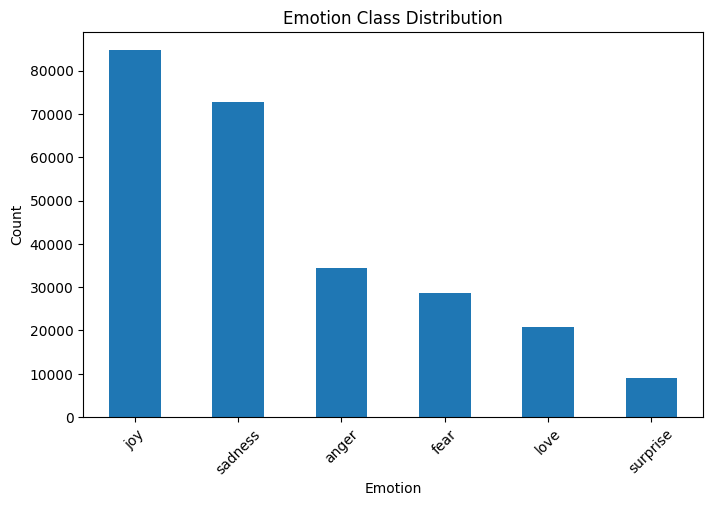

In [3]:
plt.figure(figsize=(8,5))
df['label'].value_counts().plot(kind='bar')
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-3070914616.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


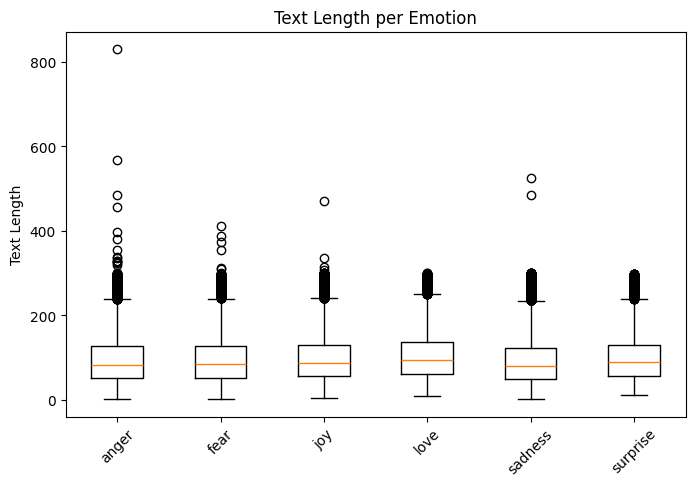

In [4]:
df['text_length'] = df['text'].str.len()

labels = df['label'].unique()
data = [df[df['label'] == l]['text_length'] for l in labels]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=labels)
plt.title("Text Length per Emotion")
plt.xticks(rotation=45)
plt.ylabel("Text Length")
plt.show()


### 2B Text Preprocessing

Kode ini digunakan untuk mengatur seed (nilai awal) pada berbagai sumber keacakan seperti Python, NumPy, dan TensorFlow. Tujuannya adalah agar hasil eksperimen bersifat reproducible, yaitu menghasilkan output yang sama ketika kode dijalankan ulang.

In [5]:
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


Setelah itu, dilakukan preprocessing teks yang meliputi pembersihan karakter khusus, penghapusan stopwords, dan normalisasi teks. Tahap ini bertujuan untuk mengurangi noise dan meningkatkan kualitas representasi teks sebelum digunakan dalam pemodelan.

In [6]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

df["clean_text"] = df["text"].apply(clean_text)

df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,id,text,label,text_length,clean_text
0,411553,i feel rebellious and i like it,anger,31,feel rebellious like
1,18079,i feel completely agitated and full of blame,anger,44,feel completely agitated full blame
2,282107,i feel like a witch bc im aggravated and i wan...,anger,81,feel like witch bc im aggravated want go like ...
3,49946,i feel really bitchy for doing this but im rea...,anger,193,feel really bitchy im really iffy read journal...
4,96367,i feel rude but i move past it immediately,anger,42,feel rude move past immediately


In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["label"]
)


LabelEncoder digunakan untuk mengubah label kategori menjadi nilai numerik agar dapat diproses oleh model.
Encoding dilakukan berdasarkan label pada data training dan diterapkan secara konsisten pada data validasi dan test untuk menjaga kesesuaian kelas.

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["label_enc"] = le.fit_transform(train_df["label"])
val_df["label_enc"]   = le.transform(val_df["label"])
test_df["label_enc"]  = le.transform(test_df["label"])

num_classes = len(le.classes_)
print(le.classes_)


['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


### 2C Bidirectional GRU Model

Teks yang telah dibersihkan diubah menjadi urutan angka menggunakan Tokenizer, lalu diseragamkan panjangnya dengan padding agar dapat diproses oleh model.
Label target dikonversi ke bentuk one-hot encoding untuk menyesuaikan dengan tugas klasifikasi multikelas.


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df["clean_text"])

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["clean_text"]),
    maxlen=100
)
X_val = pad_sequences(
    tokenizer.texts_to_sequences(val_df["clean_text"]),
    maxlen=100
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=100
)

y_train = to_categorical(train_df["label_enc"], num_classes)
y_val   = to_categorical(val_df["label_enc"], num_classes)
y_test  = to_categorical(test_df["label_enc"], num_classes)

vocab_size = len(tokenizer.word_index) + 1


Class weight dihitung untuk mengatasi ketidakseimbangan jumlah data antar kelas pada data training.
Dengan pemberian bobot ini, model akan memberikan perhatian lebih besar pada kelas minoritas saat proses pelatihan.


In [10]:
from sklearn.utils.class_weight import compute_class_weight

y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(1.2120268980871463), 1: np.float64(1.4559273005130444), 2: np.float64(0.4924495560191253), 3: np.float64(2.0103624990579547), 4: np.float64(0.5732351993123456), 5: np.float64(4.640024352061228)}


Data training dan validasi dibentuk menjadi `tf.data.Dataset` agar proses pelatihan lebih efisien.
Data training diacak dan dibagi dalam batch, serta menggunakan prefetch untuk mempercepat aliran data ke model.


In [11]:
import tensorflow as tf

BATCH_SIZE = 32

train_ds_gru = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(1000) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds_gru = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)


Model GRU dibangun menggunakan embedding untuk merepresentasikan kata, diikuti oleh dua lapisan Bidirectional GRU guna menangkap konteks urutan teks dari dua arah.
Lapisan Dropout digunakan untuk mengurangi overfitting, sedangkan lapisan Dense dengan softmax menghasilkan probabilitas untuk setiap kelas.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Bidirectional, Dense, Dropout

gru_model = Sequential([
    Embedding(vocab_size, 128),
    Bidirectional(GRU(256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(128)),
    Dense(num_classes, activation="softmax")
])

gru_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_gru = gru_model.fit(
    train_ds_gru,
    validation_data=val_ds_gru,
    epochs=15,
    steps_per_epoch=100,
    validation_steps=50,
    class_weight=class_weight_dict
)


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.1645 - loss: 1.8434 - val_accuracy: 0.5919 - val_loss: 1.3231
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5623 - loss: 1.1522 - val_accuracy: 0.8044 - val_loss: 0.6099
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8096 - loss: 0.5237 - val_accuracy: 0.9056 - val_loss: 0.3018
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8949 - loss: 0.2938 - val_accuracy: 0.9100 - val_loss: 0.3270
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9153 - loss: 0.2247 - val_accuracy: 0.9187 - val_loss: 0.2530
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9104 - loss: 0.2207 - val_accuracy: 0.9312 - val_loss: 0.1800
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9284 - loss: 0.1722 - val_accuracy: 0.9381 - val_loss: 0.1691
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9161 - loss: 0.2392 - val_acc

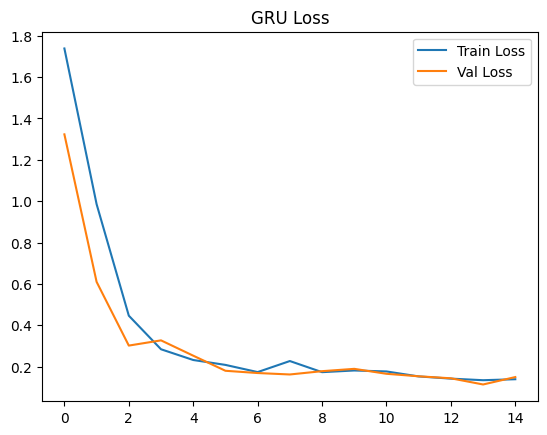

In [14]:
plt.plot(history_gru.history["loss"], label="Train Loss")
plt.plot(history_gru.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("GRU Loss")
plt.show()


Grafik menunjukkan bahwa nilai loss training dan validation menurun secara signifikan pada awal epoch dan kemudian stabil.
Hal ini menandakan bahwa model GRU berhasil belajar dengan baik tanpa indikasi overfitting yang kuat.


### 2D DistilBERT Model

Tokenizer DistilBERT digunakan untuk mengubah teks menjadi token yang sesuai dengan model pretrained DistilBERT.
Teks dipotong dan dipadding hingga panjang maksimum agar seluruh input memiliki ukuran yang seragam.


In [15]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

MAX_LEN = 128

train_enc = tokenizer(
    train_df["clean_text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="tf"
)

val_enc = tokenizer(
    val_df["clean_text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="tf"
)

test_enc = tokenizer(
    test_df["clean_text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="tf"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [16]:
import numpy as np

y_train_int = np.argmax(y_train, axis=1)
y_val_int   = np.argmax(y_val, axis=1)
y_test_int  = np.argmax(y_test, axis=1)

print("y_train_int shape:", y_train_int.shape)
print("y_val_int shape:", y_val_int.shape)
print("y_test_int shape:", y_test_int.shape)


y_train_int shape: (160053,)
y_val_int shape: (40014,)
y_test_int shape: (50017,)


Data input BERT dibentuk menjadi `tf.data.Dataset` yang berisi `input_ids` dan `attention_mask` agar sesuai dengan arsitektur model Transformer.
Dataset di-batch dan diprefetch untuk meningkatkan efisiensi pelatihan, sementara data training diacak untuk mencegah bias urutan data.


In [23]:
BATCH_SIZE = 32

train_ds_bert = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": train_enc["input_ids"],
        "attention_mask": train_enc["attention_mask"]
    },
    y_train_int
)).shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_bert = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": val_enc["input_ids"],
        "attention_mask": val_enc["attention_mask"]
    },
    y_val_int
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_bert = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": test_enc["input_ids"],
        "attention_mask": test_enc["attention_mask"]
    },
    y_test_int
)).batch(128).prefetch(tf.data.AUTOTUNE)



Model DistilBERT pretrained digunakan untuk klasifikasi teks dengan jumlah kelas sesuai data.
Sebagian besar layer dibekukan untuk mempertahankan representasi bahasa umum, sementara layer terakhir dilatih ulang agar model dapat menyesuaikan dengan tugas klasifikasi spesifik.


In [24]:
from transformers import TFDistilBertForSequenceClassification

bert_model = TFDistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6,
    use_safetensors=False
)

# Freeze most layers
bert_model.distilbert.trainable = False
bert_model.distilbert.transformer.layer[-1].trainable = True


Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_layer_norm', 'activation_13', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['dropout_39', 'pre_classifier', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [25]:
bert_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [26]:
history_bert = bert_model.fit(
    train_ds_bert,
    validation_data=val_ds_bert,
    epochs=15,
    steps_per_epoch=100,
    validation_steps=50,
    class_weight=class_weight_dict
)


Epoch 1/15
100/100 [==============================] - 48s 298ms/step - loss: 1.4892 - accuracy: 0.4356 - val_loss: 1.2613 - val_accuracy: 0.5688
Epoch 2/15
100/100 [==============================] - 26s 260ms/step - loss: 1.2677 - accuracy: 0.5278 - val_loss: 1.2628 - val_accuracy: 0.5225
Epoch 3/15
100/100 [==============================] - 28s 280ms/step - loss: 1.2656 - accuracy: 0.5294 - val_loss: 1.2033 - val_accuracy: 0.5631
Epoch 4/15
100/100 [==============================] - 22s 224ms/step - loss: 1.2775 - accuracy: 0.5384 - val_loss: 1.1150 - val_accuracy: 0.5950
Epoch 5/15
100/100 [==============================] - 22s 225ms/step - loss: 1.2224 - accuracy: 0.5497 - val_loss: 1.1320 - val_accuracy: 0.5950
Epoch 6/15
100/100 [==============================] - 23s 226ms/step - loss: 1.2225 - accuracy: 0.5475 - val_loss: 1.1265 - val_accuracy: 0.5913
Epoch 7/15
100/100 [==============================] - 22s 222ms/step - loss: 1.2068 - accuracy: 0.5503 - val_loss: 1.0621 - val_ac

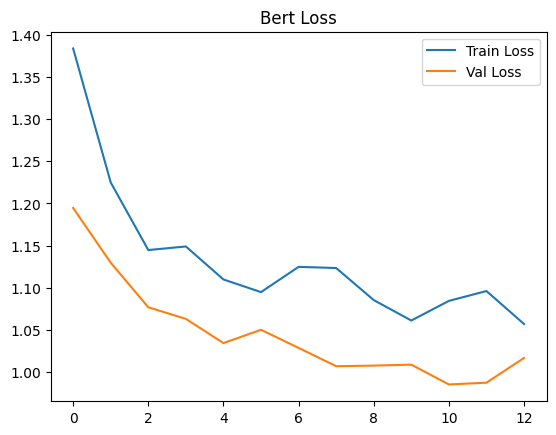

In [21]:
plt.plot(history_bert.history["loss"], label="Train Loss")
plt.plot(history_bert.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Bert Loss")
plt.show()


Grafik menunjukkan bahwa nilai training loss dan validation loss menurun secara bertahap selama epoch, menandakan proses fine-tuning berjalan dengan baik.
Validation loss yang konsisten lebih rendah dari training loss menunjukkan bahwa model tidak mengalami overfitting yang signifikan.


### 2E Evaluation & Conclusion

In [28]:
from sklearn.metrics import classification_report

y_pred_gru = gru_model.predict(X_test).argmax(axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print("GRU Results (Class Weighted)")
print(classification_report(
    y_test_labels,
    y_pred_gru,
    target_names=le.classes_
))


1564/1564 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step
GRU Results (Class Weighted)
              precision    recall  f1-score   support

       anger       0.93      0.94      0.94      6878
        fear       0.89      0.91      0.90      5725
         joy       1.00      0.90      0.95     16928
        love       0.76      1.00      0.86      4146
     sadness       0.99      0.95      0.97     14543
    surprise       0.73      1.00      0.84      1797

    accuracy                           0.94     50017
   macro avg       0.88      0.95      0.91     50017
weighted avg       0.95      0.94      0.94     50017



Model GRU dengan class weighting menunjukkan performa yang sangat baik dengan akurasi 94%, di mana sebagian besar kelas memiliki precision, recall, dan F1-score tinggi, menandakan kemampuan klasifikasi yang konsisten meskipun distribusi kelas tidak seimbang

In [29]:
from sklearn.metrics import classification_report

outputs = bert_model.predict(test_ds_bert, verbose=1)

logits = outputs.logits if hasattr(outputs, "logits") else outputs
y_pred_bert = logits.argmax(axis=1)


print("BERT Results (Class Weighted)")
print(classification_report(
    y_test_int,
    y_pred_bert,
    target_names=le.classes_,
    digits=4
))


391/391 [==============================] - 221s 566ms/step
BERT Results (Class Weighted)
              precision    recall  f1-score   support

       anger     0.6531    0.2351    0.3457      6878
        fear     0.5411    0.4073    0.4648      5725
         joy     0.6049    0.8614    0.7107     16928
        love     0.5846    0.0567    0.1033      4146
     sadness     0.5764    0.7199    0.6402     14543
    surprise     0.5528    0.1720    0.2623      1797

    accuracy                         0.5907     50017
   macro avg     0.5855    0.4087    0.4212     50017
weighted avg     0.5924    0.5907    0.5454     50017



Model BERT dengan class weighting menunjukkan performa yang relatif lebih rendah dengan akurasi 59%, di mana model cenderung bias ke kelas mayoritas seperti joy dan sadness yang memiliki recall tinggi. Sebaliknya, kelas minor seperti *love*, *anger*, dan *surprise* memiliki recall sangat rendah, menandakan model belum mampu menangkap pola emosi yang lebih jarang meskipun sudah diterapkan pembobotan kelas.